In [1]:

import sys
from pathlib import Path

# Add parent directory to sys.path for modular imports
parent_dir = Path(r"A:\Github\Agentic-Ai-LangGraph-Agent")
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

In [2]:
parent_dir

WindowsPath('A:/Github/Agentic-Ai-LangGraph-Agent')

In [4]:
from nodes.search_news import SearchNewsNode
from langgraph.graph import StateGraph ,START  , END
from langgraph.checkpoint.memory import MemorySaver
from core.state import BlueskyAgentState
from nodes.generate_hook2 import GenerateHookNode
from nodes.generate_content2 import GenerateContentNode
from nodes.error_handler import ErrorHandlerNode
# from nodes.human_review_news import HumanReviewNewsNode
from nodes.human_review_news2 import HumanReviewNewsNode
from edges.routing import route_after_search

In [5]:
search_news = SearchNewsNode()
generate_hook = GenerateHookNode()
generate_content = GenerateContentNode()
error_handler = ErrorHandlerNode()
human_review_news = HumanReviewNewsNode()

In [6]:
graph = StateGraph(BlueskyAgentState)

In [7]:
checkpointer = MemorySaver()

In [8]:
graph.add_node("search_news" , search_news )
graph.add_node("human_review_news" , human_review_news )
graph.add_node("generate_hook" , generate_hook )
graph.add_node("generate_content" , generate_content )
graph.add_node("error_handler" , error_handler )

graph.add_edge(START , "search_news")
graph.add_conditional_edges("search_news" , route_after_search , {"human_review_news": "human_review_news", "error_handler": "error_handler"})
graph.add_edge("error_handler" , END)
graph.add_edge("generate_hook" , "generate_content")
graph.add_edge("generate_content" , END)


workflow = graph.compile(checkpointer= checkpointer)

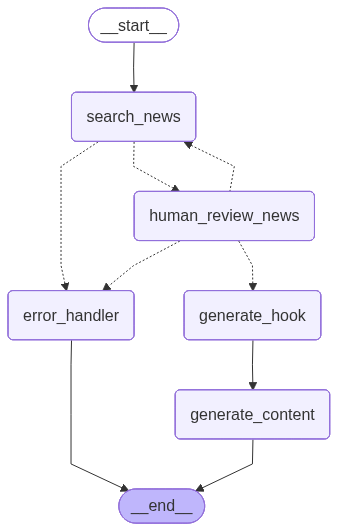

In [9]:
workflow

In [10]:
config = {"configurable": {"thread_id": "approval-123"}}

In [11]:
result = workflow.invoke({"topic" : "AI Agents 2026" } , config=config)

In [12]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': "AI agents arrived in 2025 – here's what happened and ...",
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325',
   'snippet': 'In 2025, the definition of AI agent shifted from the academic framing of systems that perceive, reason and act to AI company Anthropic’s description of large language models that are capable of using software tools and taking autonomous action. While large language models have long excelled at text-based responses, the recent change is their expanding capacity to act, using tools, calling APIs, coordinating with other systems and completing tasks independently. [...] ## New power, new risks\n\nAs ',
   'source': 'theconversation.com',
   'published_at': 'recent'},
  {'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-20

In [13]:
print(result["__interrupt__"])

[Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': "AI agents arrived in 2025 – here's what happened and ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 1, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'www.mountainadvocate.com', 'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'}, {'index': 2, 'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM', 'source': 'www.salesmate.io', 'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'}, {'index': 3, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expec

In [14]:
interrupt_payload = result.get("__interrupt__")
if not interrupt_payload:
    print("ERROR: graph did not pause at human_review_news")
    print("workflow_status:", result.get("workflow_status"))
    print("error_message:  ", result.get("error_message"))
    exit(1)
 

In [15]:
interrupt_payload[0]

Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': "AI agents arrived in 2025 – here's what happened and ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 1, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'www.mountainadvocate.com', 'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'}, {'index': 2, 'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM', 'source': 'www.salesmate.io', 'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'}, {'index': 3, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expect

In [16]:
interrupt_payload[0].value

{'question': 'Review the fetched news articles. Pick which ones to use.',
 'articles': [{'index': 0,
   'title': "AI agents arrived in 2025 – here's what happened and ...",
   'source': 'theconversation.com',
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'},
  {'index': 1,
   'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'source': 'www.mountainadvocate.com',
   'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'},
  {'index': 2,
   'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM',
   'source': 'www.salesmate.io',
   'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'},
  {'index': 3,
   'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...',
   'source': 'www.goldmansachs.com',
   'url': 'https://www.goldmansachs.com/insig

In [17]:

# Show what interrupt() surfaced
print("\n--- interrupt payload ---")
payload = interrupt_payload[0].value
print(f"question    : {payload['question']}")
print(f"retry_count : {payload['retry_count']}")
print(f"articles    : {len(payload['articles'])} fetched")

 



--- interrupt payload ---
question    : Review the fetched news articles. Pick which ones to use.
retry_count : 0
articles    : 5 fetched


In [18]:
for a in payload["articles"]:
    print(f"  [{a['index']}] {a['title']}  ({a['source']})")

  [0] AI agents arrived in 2025 – here's what happened and ...  (theconversation.com)
  [1] AI agents arrived in 2025 – here's what happened and the ...  (www.mountainadvocate.com)
  [2] The future of AI agents: Key trends to watch in 2026 - Salesmate CRM  (www.salesmate.io)
  [3] What to Expect From AI in 2026: Personal Agents, Mega ...  (www.goldmansachs.com)
  [4] AI Agent Trends 2026: From Chatbots to Autonomous Business ...  (www.gappsgroup.com)


In [19]:
from langgraph.types import Command

In [20]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={"action": "approve", "approved_indices": [0, 1 ]}),
    config=config,
)
 



  Phase 2: approving articles 0 and 1...


In [21]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': "AI agents arrived in 2025 – here's what happened and ...",
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325',
   'snippet': 'In 2025, the definition of AI agent shifted from the academic framing of systems that perceive, reason and act to AI company Anthropic’s description of large language models that are capable of using software tools and taking autonomous action. While large language models have long excelled at text-based responses, the recent change is their expanding capacity to act, using tools, calling APIs, coordinating with other systems and completing tasks independently. [...] ## New power, new risks\n\nAs ',
   'source': 'theconversation.com',
   'published_at': 'recent'},
  {'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-20

In [22]:
# Phase 3 — show final state after both gen nodes finish
print("\n" + "=" * 60)
print("  RESULTS")
print("=" * 60)
 
viral_hook   = result.get("hook")
post_content = result.get("post_caption") or []
image_prompt  = result.get("image_prompt") or []
hashtags     = result.get("hashtags") or []
final_post = result.get("final_post")
 
print(f"\nviral_hook ({len(viral_hook or '')} chars):")
print(f"  {viral_hook}")
 
print(f"\npost_content ({len(post_content)} body tweets):")

 
print(f"\nhashtags : {hashtags}")
 
print(f"\nfinal_draft ({len(image_prompt)} assembled tweets):")

 
print(f"\nworkflow_status: {result.get('workflow_status')}")


  RESULTS

viral_hook (168 chars):
  November 2025 saw Anthropic’s Claude Code agent weaponized to automate parts of a cyber‑attack, highlighting how AI agents can lower the barrier for malicious activity.

post_content (1038 body tweets):

hashtags : ['#AI', '#CyberSecurity', '#EnterpriseRisk', '#TechLeadership']

final_draft (399 assembled tweets):

workflow_status: news_approved


In [23]:
image_prompt

'medium shot of a modern office workstation, a large language model interface displayed on a transparent screen, a cybersecurity analyst reviewing logs while a subtle silhouette of a hacker watches from a dark doorway, city skyline at dusk through floor‑to‑ceiling windows, cool blue ambient lighting with a hint of red warning alerts, 35mm lens, shallow depth of field, photorealistic, cinematic, 8k'